In [25]:
!uv pip install ultralytics roboflow

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
Current directory does not exist


In [12]:
from google.colab import userdata
roboflow_api = userdata.get('roboflow_api')
from roboflow import Roboflow
rf = Roboflow(api_key = roboflow_api)

project = rf.workspace("roboflow-universe-projects").project("construction-site-safety")
version = project.version(27)
dataset = version.download("yolov8")

print("success")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Construction-Site-Safety-27 in yolov8:: 100%|██████████| 5610/5610 [00:03<00:00, 1637.16it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
success


In [13]:

print("Content of /content:")
print(os.listdir("/content"))

Content of /content:
['.config', 'dataset', 'sample_data']


In [17]:
import os

print(os.listdir("/content/dataset"))

['README.dataset.txt', 'test', 'README.roboflow.txt', 'train', 'valid', 'data.yaml']


In [19]:
with open('/content/dataset/data.yaml', 'r') as f:
    print(f.read())

names:
- Hardhat
- Mask
- NO-Hardhat
- NO-Mask
- NO-Safety Vest
- Person
- Safety Cone
- Safety Vest
- machinery
- vehicle
nc: 10
roboflow:
  license: CC BY 4.0
  project: construction-site-safety
  url: https://universe.roboflow.com/roboflow-universe-projects/construction-site-safety/dataset/27
  version: 27
  workspace: roboflow-universe-projects
test: ../test/images
train: ../train/images
val: ../valid/images



In [20]:
import yaml, os

data_yaml_path = '/content/dataset/data.yaml'

with open(data_yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Update paths to absolute paths
data['path'] = '/content/dataset'
data['train'] = 'train/images'
data['val'] = 'valid/images'
data['test'] = 'test/images'

with open(data_yaml_path, 'w') as f:
    yaml.dump(data, f)

print("data.yaml fixed:")
print(data)

data.yaml fixed:
{'names': ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle'], 'nc': 10, 'roboflow': {'license': 'CC BY 4.0', 'project': 'construction-site-safety', 'url': 'https://universe.roboflow.com/roboflow-universe-projects/construction-site-safety/dataset/27', 'version': 27, 'workspace': 'roboflow-universe-projects'}, 'test': 'test/images', 'train': 'train/images', 'val': 'valid/images', 'path': '/content/dataset'}


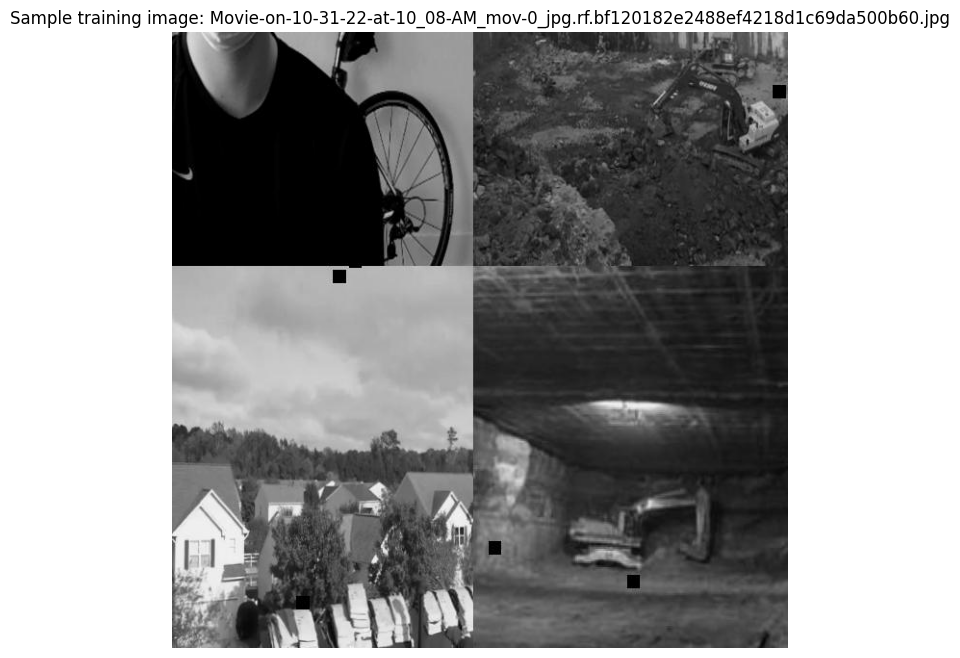

Total train images: 2603


In [28]:
import matplotlib.pyplot as plt
import cv2, os

img_dir = '/content/dataset/train/images'
img_file = os.listdir(img_dir)[0]
img_path = os.path.join(img_dir, img_file)

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(img_rgb)
plt.title(f"Sample training image: {img_file}")
plt.axis('off')
plt.show()

print(f"Total train images: {len(os.listdir(img_dir))}")

In [36]:
!yolo detect train \
  data=/content/dataset/data.yaml \
  model=yolov8n.pt \
  epochs=50 \
  imgsz=640 \
  batch=16 \
  name=safeguard_v1 \
  patience=10 \
  device=0 \
  verbose=True

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=safeguard_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10,


image 1/1 /content/dataset/valid/images/class1_267_jpg.rf.ab7a08d97aba5b0748e976df6e65700a.jpg: 640x640 1 Hardhat, 1 NO-Hardhat, 2 NO-Masks, 2 NO-Safety Vests, 2 Persons, 1 vehicle, 8.8ms
Speed: 2.4ms preprocess, 8.8ms inference, 16.2ms postprocess per image at shape (1, 3, 640, 640)


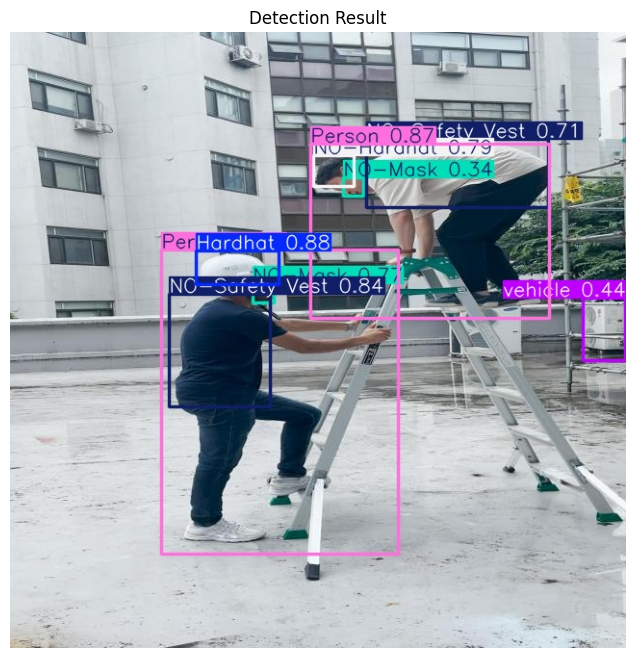

In [38]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import os

# Load your trained model
model = YOLO('/content/runs/detect/safeguard_v1/weights/best.pt')

# Pick one validation image
val_dir = '/content/dataset/valid/images'
test_img = os.path.join(val_dir, os.listdir(val_dir)[0])

# Run inference
results = model(test_img)
results[0].save('test_output.jpg')

# Show result
img = Image.open('test_output.jpg')
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.title('Detection Result')
plt.show()

In [39]:
from google.colab import files

model_path = '/content/runs/detect/safeguard_v1/weights/best.pt'
files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
from ultralytics import YOLO

# Load trained model
model = YOLO("/content/runs/detect/safeguard_v1/weights/best.pt")

# Evaluate on test split
metrics = model.val(
    data="/content/dataset/data.yaml",
    split="test"   # uses test: in data.yaml
)

print(f"mAP50: {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Precision (mp): {metrics.box.mp:.3f}")
print(f"Recall (mr): {metrics.box.mr:.3f}")

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1557.0±465.6 MB/s, size: 67.6 KB)
val: Scanning /content/dataset/test/labels... 82 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 2.0Kit/s 0.0s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.4it/s 4.3s
                   all         82        760      0.877      0.625      0.702      0.415
               Hardhat         30        110      0.988      0.748      0.855      0.523
                  Mask         16         28      0.991       0.75      0.777      0.547
            NO-Hardhat         25         41      0.794      0.585      0.564       0.29
               NO-Mask         30         79      0.863      0.559      0.715      0.299
   

In [41]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/safeguard_v1/weights/best.pt")
metrics = model.val(
    data="/content/dataset/data.yaml",
    split="test"
)

print(f"mAP50: {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall: {metrics.box.mr:.3f}")

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2349.3±780.7 MB/s, size: 53.6 KB)
val: Scanning /content/dataset/test/labels.cache... 82 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 28.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.8it/s 3.3s
                   all         82        760      0.877      0.625      0.702      0.415
               Hardhat         30        110      0.988      0.748      0.855      0.523
                  Mask         16         28      0.991       0.75      0.777      0.547
            NO-Hardhat         25         41      0.794      0.585      0.564       0.29
               NO-Mask         30         79      0.863      0.559      0.715      0.299
        NO-Safety Vest         36         90      0.903

In [42]:
import json, os

results_dir = "/content/experiments"
os.makedirs(results_dir, exist_ok=True)

results_dict = {
    "mAP50": float(metrics.box.map50),
    "mAP50_95": float(metrics.box.map),
    "precision": float(metrics.box.mp),
    "recall": float(metrics.box.mr)
}

with open(os.path.join(results_dir, "metrics_test.json"), "w") as f:
    json.dump(results_dict, f, indent=4)

print("Saved metrics to", os.path.join(results_dir, "metrics_test.json"))

Saved metrics to /content/experiments/metrics_test.json


In [43]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import os

model = YOLO("/content/runs/detect/safeguard_v1/weights/best.pt")

val_dir = "/content/dataset/valid/images"
img_name = os.listdir(val_dir)[0]
img_path = os.path.join(val_dir, img_name)

results = model(img_path)
results[0].save(os.path.join(results_dir, "sample_detection.jpg"))

print("Saved sample detection to", os.path.join(results_dir, "sample_detection.jpg"))


image 1/1 /content/dataset/valid/images/class1_267_jpg.rf.ab7a08d97aba5b0748e976df6e65700a.jpg: 640x640 1 Hardhat, 1 NO-Hardhat, 2 NO-Masks, 2 NO-Safety Vests, 2 Persons, 1 vehicle, 14.5ms
Speed: 3.1ms preprocess, 14.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Saved sample detection to /content/experiments/sample_detection.jpg
